<a href="https://colab.research.google.com/github/nitindavegit/Deep-Learning/blob/main/pytorch12_cnn_fashion_mnist_gpu_optimized_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
# check gpu is available or not
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cuda


In [ ]:
df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


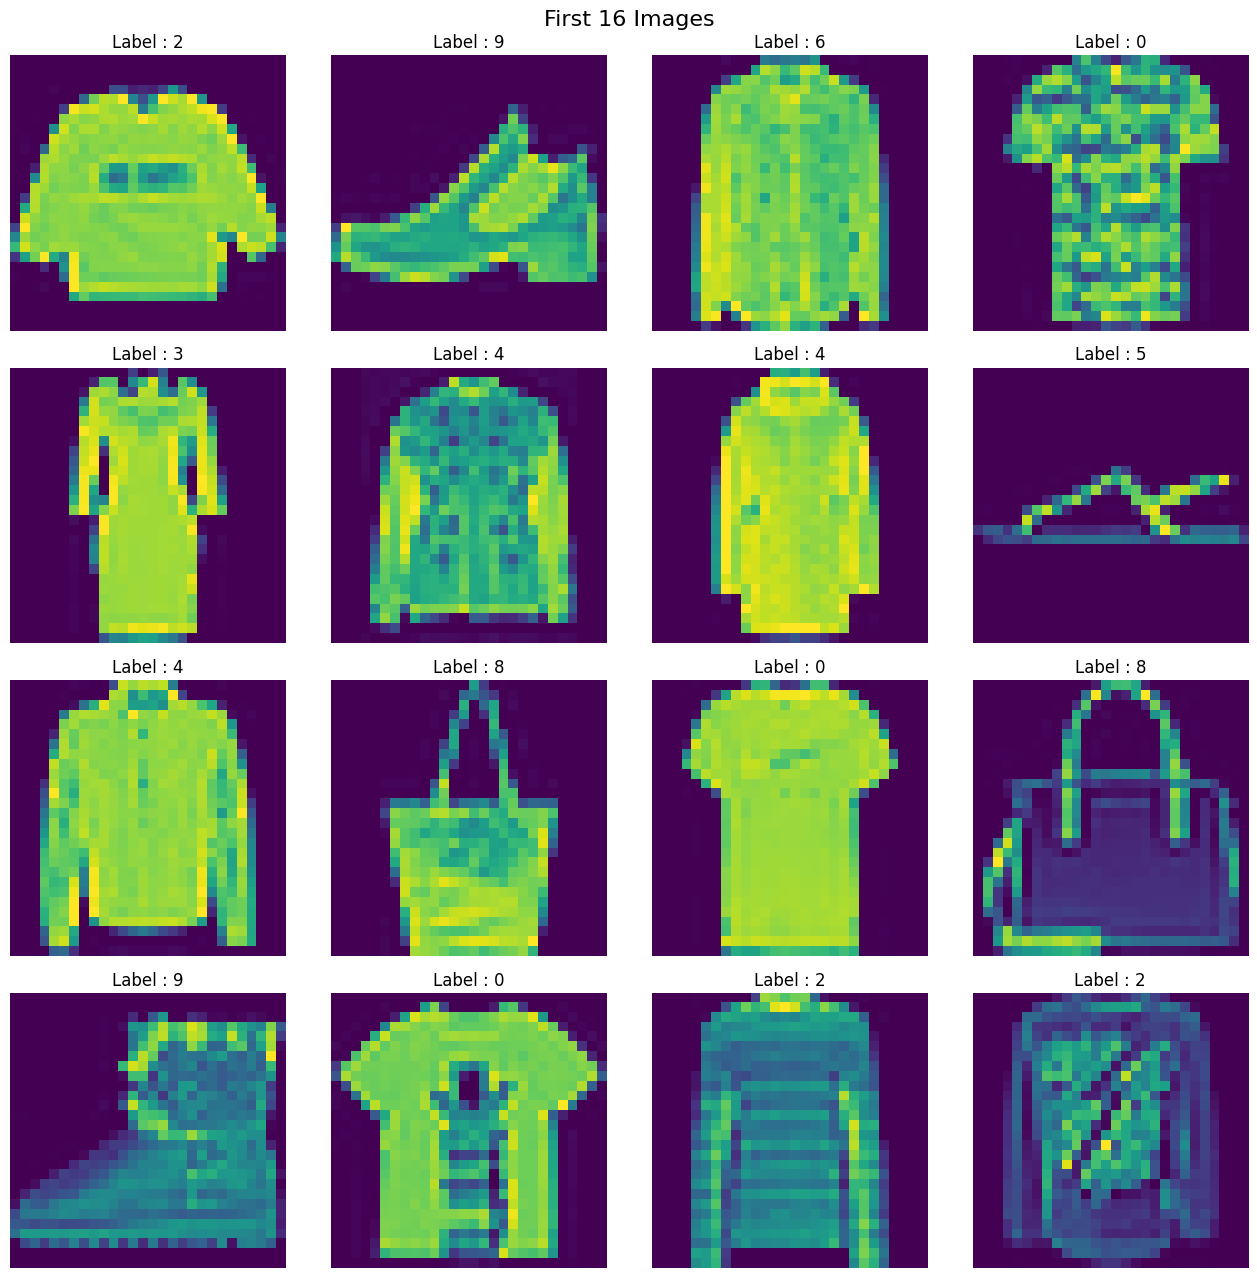

In [ ]:

fig, axes = plt.subplots(4,4, figsize=(13,13))
fig.suptitle("First 16 Images", fontsize=16)
for i , ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label : {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,1])
plt.show()


In [ ]:
X = df.iloc[:, 1:]
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
# Scaling
X_train = X_train / 255.0
X_test = X_test / 255.0

## Reshape the flatten image into an image size (1,28,28)

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features.values, dtype=torch.float32).reshape(-1,1,28,28)   # reshaping the data
    self.labels = torch.tensor(labels.values, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [ ]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:

train_dataloader = DataLoader(train_dataset,batch_size=32, shuffle=True, pin_memory=True )
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True )

In [ ]:
class MyNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()
    self.features = nn.Sequential(        #
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )
    self.classifier = nn.Sequential(      #
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(p=0.4),


        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64,10)
    )

  def forward (self, features):
    x = self.features(features)    #
    x = self.classifier(x)
    return x

In [ ]:
learning_rate = 0.01
epochs = 100

In [ ]:
model = MyNN(1)

model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [ ]:
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_dataloader:

    # loading batch features and batch labels into GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    y_pred = model(batch_features)
    loss = criterion(y_pred, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_dataloader)
  print(f"Epoch : {epoch + 1}, Loss : {avg_loss}")

Epoch : 1, Loss : 0.6452996523777644
Epoch : 2, Loss : 0.38601511289179324
Epoch : 3, Loss : 0.3278916040584445
Epoch : 4, Loss : 0.290248555727303
Epoch : 5, Loss : 0.2651431308562557
Epoch : 6, Loss : 0.24396889510254066
Epoch : 7, Loss : 0.22948609182114402
Epoch : 8, Loss : 0.21251108084370693
Epoch : 9, Loss : 0.199073077072079
Epoch : 10, Loss : 0.1880426187571138
Epoch : 11, Loss : 0.17363762047948936
Epoch : 12, Loss : 0.1669572244392087
Epoch : 13, Loss : 0.1556390535046036
Epoch : 14, Loss : 0.14957501216931268
Epoch : 15, Loss : 0.14574436642850438
Epoch : 16, Loss : 0.13578275775785248
Epoch : 17, Loss : 0.12690162260333698
Epoch : 18, Loss : 0.1228708252577732
Epoch : 19, Loss : 0.1130697974426051
Epoch : 20, Loss : 0.10996748709181944
Epoch : 21, Loss : 0.10369262820420166
Epoch : 22, Loss : 0.09972966580310215
Epoch : 23, Loss : 0.09244980315848564
Epoch : 24, Loss : 0.08691406686433281
Epoch : 25, Loss : 0.0834365830233631
Epoch : 26, Loss : 0.07974015364136236
Epoch : 

In [ ]:
model.eval()

total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_labels in test_dataloader:


    # Loading batch features and batch labels in train dataset into GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    y_pred = model(batch_features)

    total = total + batch_labels.shape[0]

    _,predicted = torch.max(y_pred,1)

    correct=  correct + (predicted == batch_labels).sum().item()



avg_accuracy = correct/total
print(f"Accuracy: {avg_accuracy}")

Accuracy: 0.9249166666666667
